# Pytorch Neural Network: MNIST dataset

This problem demonstrates understanding of training and evaluating a neural network using the MNIST dataset.
Tools used: Python, torchvision for the dataset, and PyTorch for building and training the neural network.

In [2]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import pandas as pd

learning_rate = 3*1e-3
batch_size = 64
epochs = 12

## Load MNIST Dataset

The following cell loads the MNIST dataset, which contains images of handwritten digits.

In [3]:
# Load the MNIST training dataset
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

# Load the MNIST testing dataset
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Setup Data Loaders for Training and Testing

Create data loaders for the training and testing datasets.

In [4]:
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Custom Neural Network Model Using `nn.Module`

The `im_width` and `im_height` variables represent the width and height of the input images, respectively. The first hidden layer have 512 units. The second hidden layer have 512 units. The output layer have 10 units corresponding to the 10 digit classes.

In [5]:
im_width = 28
im_height = 28
hidden1 = 512
hidden2 = 512

class NeuralNetwork(nn.Module):
    def __init__(self, im_width, im_height, hidden1, hidden2):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Flatten(),
            nn.Linear(im_width * im_height, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)
        )
    
    def forward(self, x):
        logits = self.cnn(x)
        return logits
    

## Training Loop Function


In [6]:
import numpy as np
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    print("Training")
    losses = []
    processed_batch_instances = []
    total_batches = len(dataloader)
    total_instances = len(dataloader.dataset)
    batch_no = 0
    current_loss = 0
    for batch_no, (data, target) in enumerate(dataloader):
        optimizer.zero_grad()
        logits = model(data)
        loss = loss_fn(logits, target)
        loss.backward()
        current_loss = loss.item()
        losses.append(current_loss)
        optimizer.step()
        current_batch_size = data.size(0)
        processed_batch_instances.append(current_batch_size)
        if (batch_no + 1) % 100 == 0:
            print(f"Batch {batch_no+1}/{total_batches} | Instances {sum(processed_batch_instances)}/{total_instances} | Loss: {current_loss:.7f}")
    # last print
    if batch_no:
        print(f"Batch {batch_no+1}/{total_batches} | Instances {sum(processed_batch_instances)}/{total_instances} | Loss: {current_loss:.7f}")

    avg_loss = np.mean(losses)
    print(f"Average Training Loss: {avg_loss:.7f}")
    return avg_loss

## Evaluation Loop Function


In [7]:
def test_loop(dataloader, model, loss_fn):
    model.eval()
    print("Test Validation")
    losses = []
    processed_batch_instances = []
    total_batches = len(dataloader)
    total_instances = len(dataloader.dataset)
    batch_no = 0
    current_loss = 0

    correct = 0
    with torch.no_grad():
        for batch_no, (data, targets) in enumerate(dataloader):
            outputs = model(data)
            loss = loss_fn(outputs, targets)
            current_loss = loss.item()
            losses.append(current_loss)

            current_batch_size = data.size(0)
            processed_batch_instances.append(current_batch_size)

            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == targets).sum().item()
            if (batch_no + 1) % 100 == 0:
                print(f"[Testing] Batch {batch_no+1}/{total_batches} | Instances {sum(processed_batch_instances)}/{total_instances} | Loss: {current_loss:.7f}")

    # last print
    if batch_no:
        print(f"[Testing] Batch {batch_no+1}/{total_batches} | Instances {sum(processed_batch_instances)}/{total_instances} | Loss: {current_loss:.7f}")

    avg_loss = np.mean(losses)
    accuracy = correct / total_instances
    print(f"Average Testing Loss: {avg_loss:.7f} Accuracy: {accuracy:.7f}")
    return avg_loss, accuracy

## Loss, instantiating the model, and optimizer


In [8]:
loss_fn = nn.CrossEntropyLoss()
model = NeuralNetwork(im_width, im_height, hidden1, hidden2)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.99)

## Train the Model and Store Metrics

In [9]:
training_loss, testing_loss, accuracy_curve = [], [], []
for t in range(epochs):
    print(f"\nEpoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_accuracy = test_loop(test_dataloader, model, loss_fn)
    training_loss.append(train_loss)
    testing_loss.append(test_loss)
    accuracy_curve.append(test_accuracy)

print("Done!")


Epoch 1
-------------------------------
Training
Batch 100/938 | Instances 6400/60000 | Loss: 1.0643038
Batch 200/938 | Instances 12800/60000 | Loss: 1.0812912
Batch 300/938 | Instances 19200/60000 | Loss: 0.2450741
Batch 400/938 | Instances 25600/60000 | Loss: 0.4310035
Batch 500/938 | Instances 32000/60000 | Loss: 0.1348288
Batch 600/938 | Instances 38400/60000 | Loss: 0.0944730
Batch 700/938 | Instances 44800/60000 | Loss: 0.3410798
Batch 800/938 | Instances 51200/60000 | Loss: 0.1147302
Batch 900/938 | Instances 57600/60000 | Loss: 0.1320206
Batch 938/938 | Instances 60000/60000 | Loss: 0.1358026
Average Training Loss: 0.5153034
Test Validation
[Testing] Batch 100/157 | Instances 6400/10000 | Loss: 0.0977762
[Testing] Batch 157/157 | Instances 10000/10000 | Loss: 0.0439599
Average Testing Loss: 0.1439627 Accuracy: 0.9564000

Epoch 2
-------------------------------
Training
Batch 100/938 | Instances 6400/60000 | Loss: 0.1274378
Batch 200/938 | Instances 12800/60000 | Loss: 0.130748

## Plot Training and Testing Loss

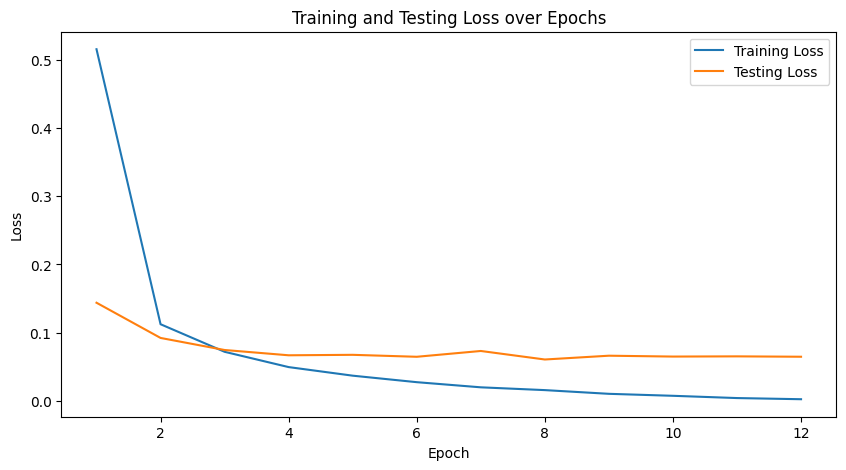

In [10]:
# Create a DataFrame for the losses
losses_df = pd.DataFrame({
    "Epoch": np.arange(1, epochs+1),
    "Training Loss": training_loss,
    "Testing Loss": testing_loss,
})

# Plot the training and testing loss
plt.figure(figsize=(10, 5))
plt.plot(losses_df['Epoch'], losses_df['Training Loss'], label='Training Loss')
plt.plot(losses_df['Epoch'], losses_df['Testing Loss'], label='Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss over Epochs')
plt.legend()
plt.show()